In [1]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
import ast
import matplotlib.dates as mdates
from datetime import timedelta
myFmt = mdates.DateFormatter('%H:%M:%S') 


In [30]:
def time_reader(f, time_correction=False):
    f=open(f)
    lines = f.readlines()
    time_map = {} 
    #start datetime: {end datetime: e_dt, network latency per img: nw, 
    # compute latency per imd : comp, throughput: th, batch_size: bs, num_batches: nb, 
    # total_time: e_dt - start_dt, (apply day correction if required) 
    # network latency total: nw_t, compute latency total: comp_t, 
    # flop: fp, s_per_op: s*10**9/op, nw_std: 0, comp_std: 0 } 
    dt_st=0
    dt_et=0
    last_iter = 0
    last_rank=False
    for line in lines:
        line=line.strip()
        if "startheat" in line:
            st = line.split("TIME:")[-1]
            dt_st = datetime.strptime(st, "%H:%M:%S.%f")
        if "Gloo" in line:
            # [Gloo] Rank 1 is connected to 2 peer ranks. Expected number of connected peer ranks is : 2
            rank = line.split(" ")[2]
            world = line.split(" ")[-1]
            last_rank = (rank==world)

        if "FLOP count" in line:
            #this means it was successful (probably)
            #create dict object here
            # rank 0 FLOP count: 472055808 and full time*10**9 s/op: 0.3508
            flop = line.split("count: ")[-1].split(" and ")[0]
            s_per_op = line.split("s/op: ")[-1]
            local_rank=0
            if "rank" in line:
                local_rank = line.split("rank ")[-1].split(" ")[0]

            if dt_st==0:
                dt_st=1
                dt_et=1
                time_map[dt_st]={}
            time_map[dt_st] = {"e_dt":0, "nw":0, "comp":0, "th":0, "bs":0, "nb":0, "total_time":0, "rank":int(local_rank),  
            "nw_t":0, "comp_t":0, "flop":int(flop), "s_per_op": float(s_per_op), "nw_std": 0, "comp_std": 0}
        elif "Time taken by rank:" in line:
            # Time taken by rank:1 in total(avg): 0.2246s 
            # Batch time sets raw:[[0.0576, 0.0]] 
            # Network sets raw:[[0.166, 0]] 
            # bytes sent:[] 
            # bytes recv:1605632 on 
            # avg per image: 0.0561s with std: 0.0000s 
            # network time: 0.0830s and network std: 0.0830s 
            # network time per img: 0.0207 compute time: 0.0354s 
            # compute/network ratio: 0.4264 and throughput 17.8129 img/s

            if dt_st==0:
                dt_st=1
                dt_et=1
                time_map[dt_st]={}
            nw_t = line.split("network time: ")[-1].split("s")[0]
            nw = line.split("network time per img: ")[-1].split(" ")[0]
            nw_std = line.split("network std: ")[-1].split("s")[0]
            comp_t = line.split("total(avg): ")[-1].split("s")[0]
            comp = line.split("avg per image: ")[-1].split("s")[0]
            comp_std = line.split("with std: ")[-1].split("s")[0]
            th = line.split("throughput ")[-1].split(" ")[0]
            recv = line.split("recv:")[-1].split(" ")[0]
            sent = ast.literal_eval("["+line.split("sent:[")[-1].split("] ")[0]+"]")
            if len(sent)>0:
                sent=sent[-1][-1]
            else:
                sent=0

            time_map[dt_st]["nw_t"] = float(nw_t)
            time_map[dt_st]["nw"] =  float(nw)
            time_map[dt_st]["nw_std"]=float(nw_std)
            time_map[dt_st]["comp_t"] =float(comp_t)
            time_map[dt_st]["comp"] = float(comp)
            time_map[dt_st]["comp_std"]=float(comp_std)
            time_map[dt_st]["th"]=float(th)
            time_map[dt_st]["sent"]=float(sent)
            time_map[dt_st]["recv"]=float(recv)

            block_times = ast.literal_eval(line.split("Batch time sets raw:")[-1].split("] ")[0]+"]")[-1]
            net_times = ast.literal_eval(line.split("Network sets raw:")[-1].split("] ")[0]+"]")[-1]            
            #combine lists and then np.cumulative_sum to get the block boundaries
            #plot them against throttle points and heatmap maybe? 
            #start on network, end on network, if any remaining compute -> leave as is
            timing = []
            while True:
                net_p = net_times.pop(0)
                timing.append(net_p)
                if len(net_times) == 0:
                    break
                comp_p = block_times.pop(0)
                timing.append(comp_p)
            if last_rank: #corner case when rank=world, checks gloo message to verify last rank
                timing.append(block_times.pop(0))

               
            time_map[dt_st]["timing"] = np.cumulative_sum([it for it in timing])
            #even index on cumulative sum is network, odd index is compute        

        if "Sync done" in line:
            # 2026-03-17 13:59:28.033112 Sync done -> model run start
            last_iter = datetime.strptime(line.split(" ")[1].split(".")[0], "%H:%M:%S") #this is compared against heatfiles
        if "endheat" in line:
            et  = line.split("TIME:")[-1]
            if dt_st not in time_map:
                break
            dt_et = datetime.strptime(et, "%H:%M:%S.%f")
            time_map[dt_st]["e_dt"] = dt_et
    
    if dt_et==0 or dt_st==0:
        return None, None
    if time_correction:
        pass

         
    return time_map, last_iter

def heat_reader(f, last_iter=None, time_correction=False):
    f=open(f)
    lines=f.readlines()
    heat_map={}
    #{dt:{temp:t, volt:v, freq:f, throttled:t, total_volt: tv}}
    for l in range(len(lines)-2):
        line=lines[l]
        line=line.strip()
        # TIME:17:49:20
        # 32172
        # freq:frequency(48)=1400000000,throttle_flag:throttled=0x50000,voltage:volt=1.3500V,volt=1.2500V,volt=1.2500V,volt=1.2250V
        if "TIME:" in line:
            dt = datetime.strptime(line.split("TIME:")[-1], "%H:%M:%S")
            if last_iter!=None and dt < last_iter:
                continue
            temp_line = lines[l+1].strip()
            # print("here?")
            if "TIME" not in temp_line and "freq" not in temp_line:
                # cpu:average: 0.71, 0.54,,freq:frequency(48)=700000000,throttle_flag:throttled=0x50000,voltage:volt=1.2375V,volt=1.2500V,volt=1.2500V,volt=1.2250V
                # or
                # cpu:1.16, 0.61, 0.35,freq:frequency(48)=600000000,throttle_flag:throttled=0x50005,voltage:volt=1.2000V,volt=1.2500V,volt=1.2500V,volt=1.2250V

                temp = float(temp_line)/10**3
                freq_line = lines[l+2]
                if "volt" in freq_line:
                    freq = float(freq_line.split("freq:")[-1].split("=")[1].split(",")[0])*10**-9
                    throttled = (freq_line.split("throttled=")[1].split(",")[0][-1] == "0")
                    volts = [ float(v.split("volt=")[-1].split("V")[0]) for v in freq_line.split("voltage:")[-1].split(",")]
                    alt_cpu = freq_line.split("cpu:")[-1].split(",")[0] if "average" not in freq_line else freq_line.split("average: ")[-1].split(",")[0]
                    cpu = float(alt_cpu)
                    heat_map[dt]={"cpu":cpu, "temp":temp, "volt":volts[0], "freq":freq, "throttled": throttled, "total_volt":sum(volts)}
                else:
                    continue

            else:
                continue
    if time_correction:
        pass

    return heat_map


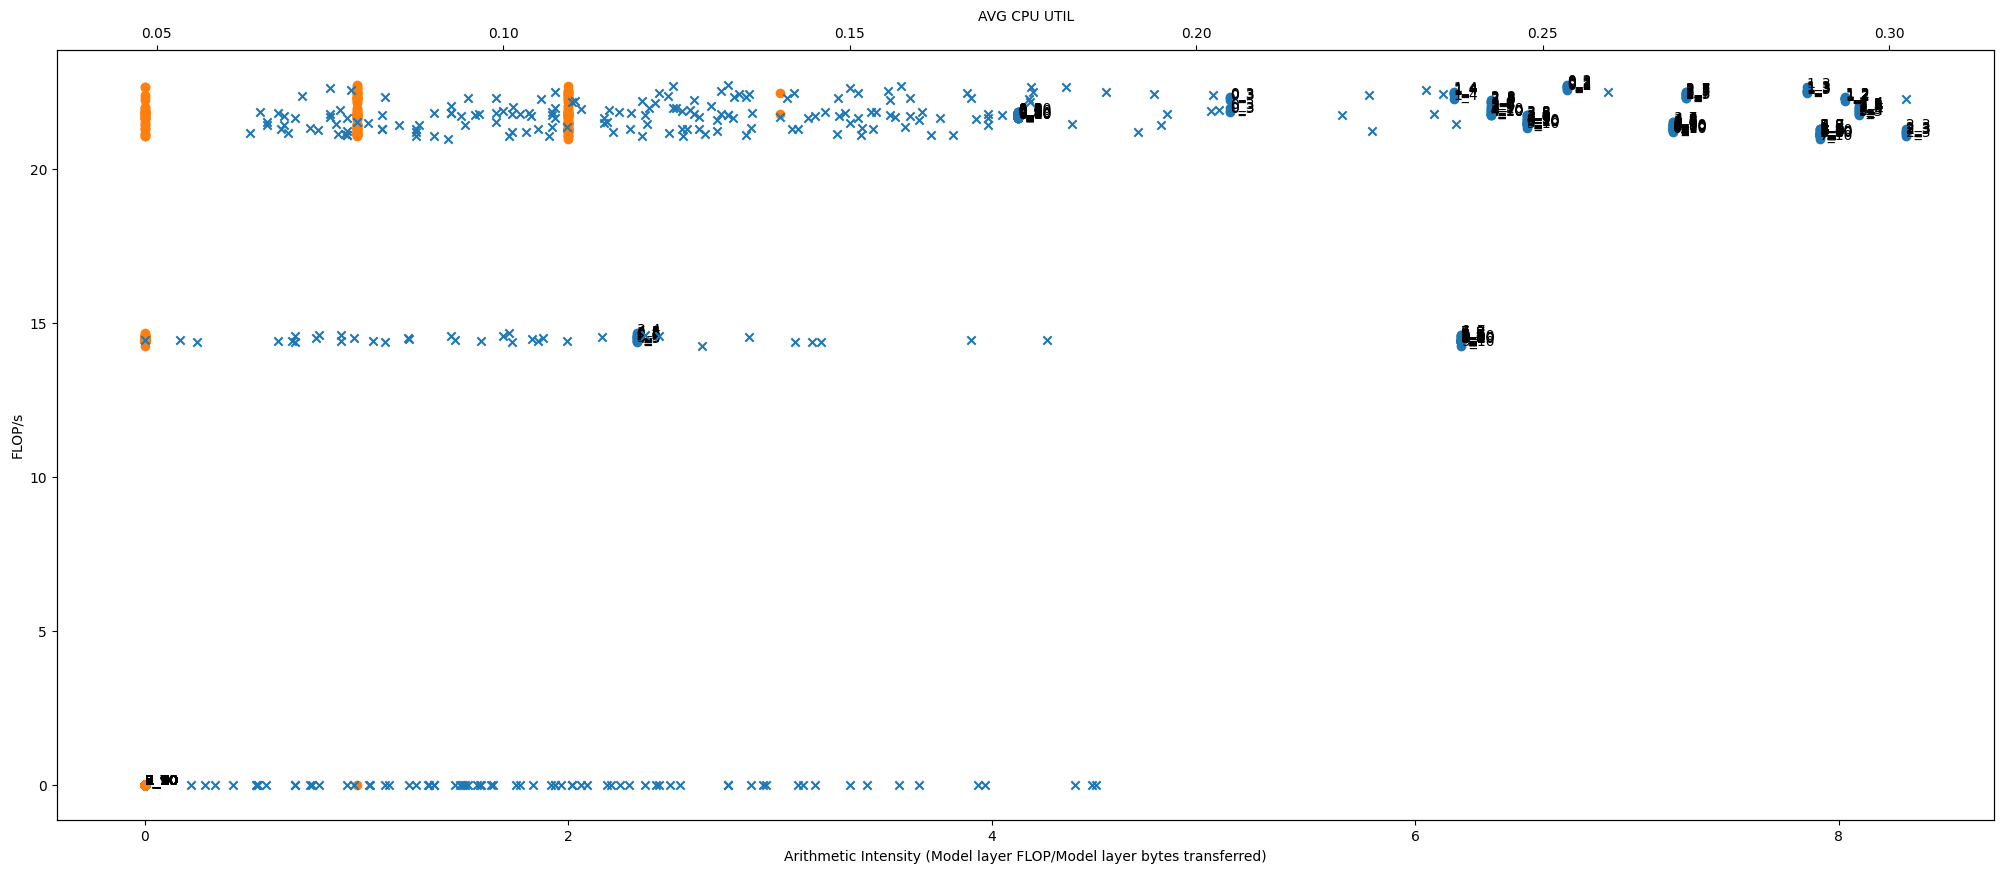

In [50]:
#on the pis

arith_intensity = [] #flops/bytes
flop_per_s = [] #flops/s
throttled_info = []
tags = []
cpu = []
num_cores=4
for repeat in range(1,11):
    for i in [2,3,4,5,7,8,9,10]:
        for batch in [2]:
            for rank in range(1,43):#range(0,i):
                pdu="bramble-4-5"
                c_fname = f"/Users/animeshnd/model_splitting/logs/roofline/resnet18_children/{repeat}/{i}_size/{batch}/speed_chronos{pdu}-{rank}.log"
                h_fname = f"/Users/animeshnd/model_splitting/logs/roofline/resnet18_children/{repeat}/{i}_size/{batch}/speed_heat{pdu}-{rank}.log"
                if Path(c_fname).is_file() and Path(h_fname).is_file():
                    # print(c_fname)
                    time_map, last_iter = time_reader(c_fname)
                    if time_map==None:
                        continue
                    flop = time_map[1]["flop"]
                    comp_t = time_map[1]["comp"]
                    sent_b = time_map[1]["sent"]
                    recv_b = time_map[1]["recv"]
                    l_rank = time_map[1]["rank"]
                    flop_per_s.append(flop/comp_t)
                    arith_intensity.append(flop/(sent_b+recv_b))
                    tags.append(f"{l_rank}_{i}")

                    heat_map = heat_reader(h_fname, last_iter)
                    # print(heat_map)
                    temp_cpu = [t['cpu'] for t in heat_map.values()]
                    temp_thr = [1 for t in heat_map.values() if t["throttled"]==False]
                    # print(temp_cpu)
                    cpu.append( (np.mean(temp_cpu)/num_cores))
                    throttled_info.append( sum(temp_thr) )
                    # cpu.append( np.max(temp_cpu)/num_cores)
                    # print(heat_map)
                    # break
                # break
            # break
        # break

fig, axs = plt.subplots(figsize=(25,10))
# print(arith_intensity, flop_per_s)
arith_intensity = [ np.log(i if i != 0 else 1) for i in arith_intensity]
flop_per_s = [ np.log(i if i != 0 else 1 ) for i in flop_per_s]
axs.scatter(arith_intensity, flop_per_s)
axs.set_xlabel("Arithmetic Intensity (Model layer FLOP/Model layer bytes transferred)")
axs.set_ylabel("FLOP/s")
ax1 = axs.twiny()
ax1.scatter(cpu, flop_per_s, marker="x")
ax1.set_xlabel("AVG CPU UTIL")
axs.scatter(throttled_info, flop_per_s)
# print("here too?")
# # axs.axhline(y=flop_per_s[0])
# # axs.axhline(y=flop_per_s[0]*1/10) #pretending 10% range to theoretical max?
for r in range(len(arith_intensity)):
    axs.text(arith_intensity[r], flop_per_s[r], tags[r])
# axs.loglog()
# print("maybe here?")

[]

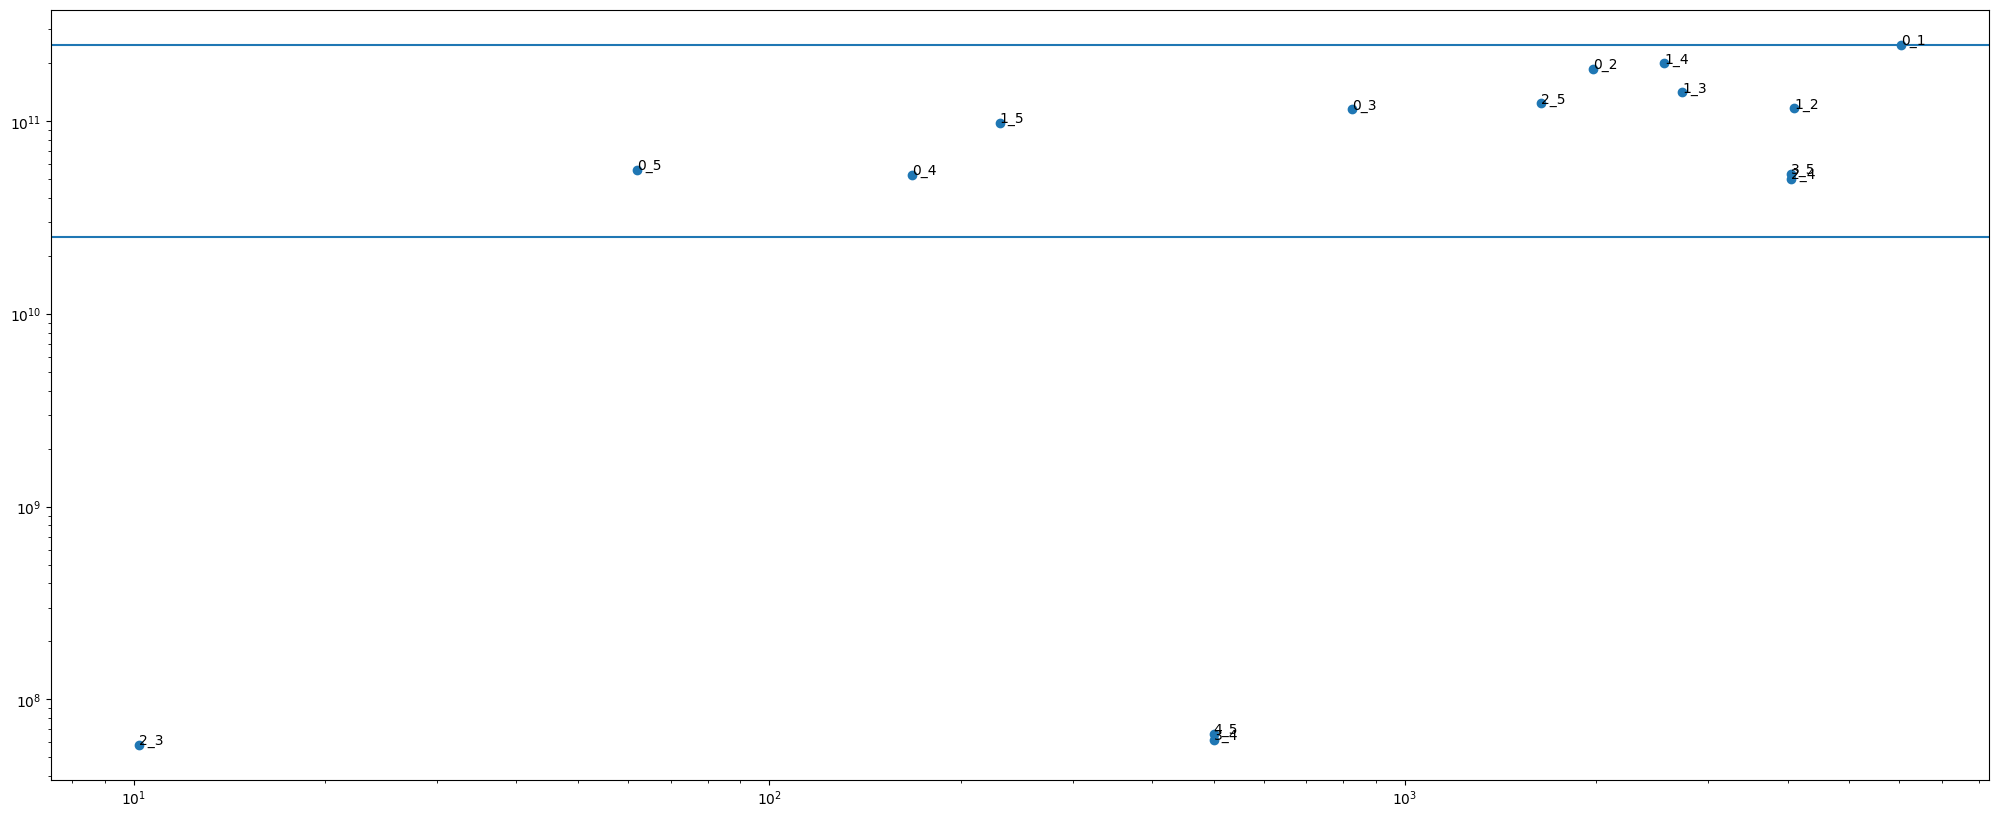

In [37]:
arith_intensity = [] #flops/bytes
flop_per_s = [] #flops/s
tags = []
for i in [1,2,3,4,5]:
    for rank in range(0,i):
        fname = f"/Users/animeshnd/model_splitting/logs/roofline/{i}_size/speed_chronos{rank}.log"
        time_map, last_iter = time_reader(fname)
        flop = time_map[1]["flop"]
        comp_t = time_map[1]["comp"]
        sent_b = time_map[1]["sent"]
        recv_b = time_map[1]["recv"]
        flop_per_s.append(flop/comp_t)
        arith_intensity.append(flop/(sent_b+recv_b))
        tags.append(f"{rank}_{i}")
        # print(fname)
        # print(time_map)
    #     break
    # break

fig, axs = plt.subplots(figsize=(25,10))
axs.scatter(arith_intensity, flop_per_s)
axs.axhline(y=flop_per_s[0])
axs.axhline(y=flop_per_s[0]*1/10) #pretending 10% range to theoretical max?
for r in range(len(arith_intensity)):
    axs.text(arith_intensity[r], flop_per_s[r], tags[r])
axs.loglog()


[]

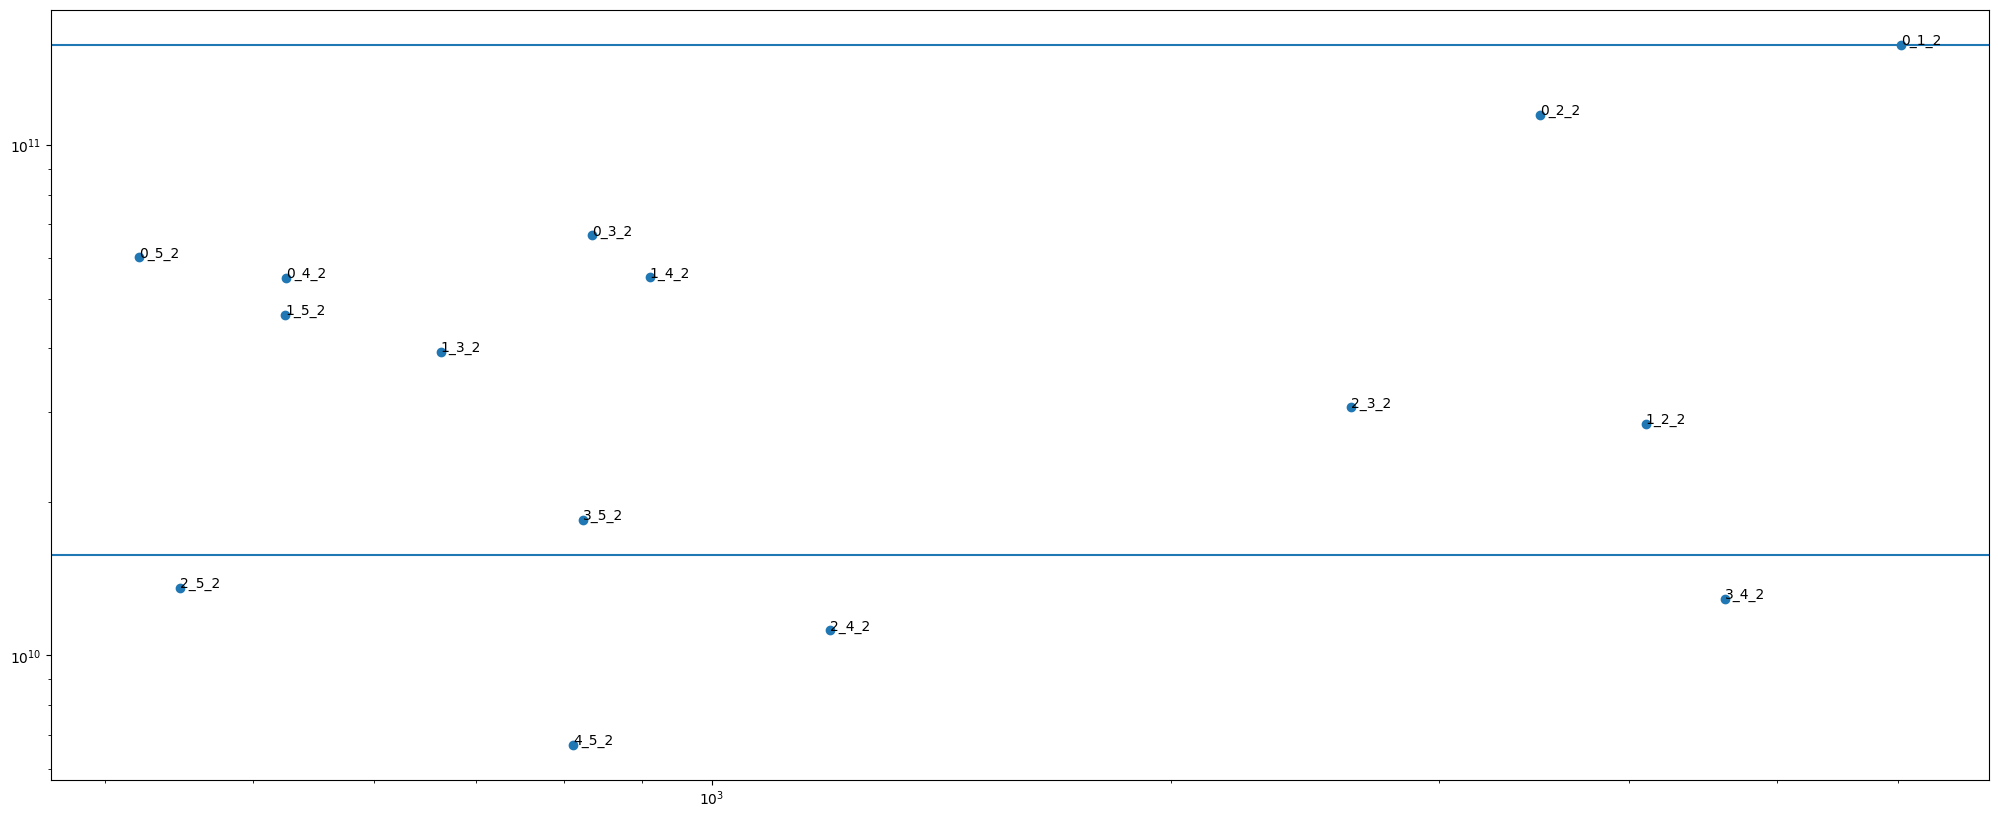

: 

In [52]:
arith_intensity = [] #flops/bytes
flop_per_s = [] #flops/s
tags = []
flops_per_batch = {}
for i in [1,2,3,4,5]:
    if i not in flops_per_batch:
        flops_per_batch[i] = {}
    for batch_size in [2]:#[2,4,6]:
        if batch_size not in flops_per_batch[i]:
            flops_per_batch[i][batch_size]={}
        for rank in range(0,i):
            # fname = f"/Users/animeshnd/model_splitting/logs/roofline/mb_smol/{i}_size/{batch_size}/speed_chronos{rank}.log"
            fname = f"/Users/animeshnd/model_splitting/logs/roofline/resnet_18/{i}_size/{batch_size}/speed_chronos{rank}.log"
            time_map, last_iter = time_reader(fname)
            flop = time_map[1]["flop"]
            comp_t = time_map[1]["comp"]
            sent_b = time_map[1]["sent"]
            recv_b = time_map[1]["recv"]
            flop_per_s.append(flop/comp_t)
            arith_intensity.append(flop/(sent_b+recv_b))
            tags.append(f"{rank}_{i}_{batch_size}")
            # print(fname)
            # print(time_map)
        #     break
        # break

fig, axs = plt.subplots(figsize=(25,10))
axs.scatter(arith_intensity, flop_per_s)
for i in flop_per_s[:1]:
    axs.axhline(y=i)
    axs.axhline(y=i*1/10) #pretending 10% range to theoretical max?
for r in range(len(arith_intensity)):
    axs.text(arith_intensity[r], flop_per_s[r], tags[r])
axs.loglog()
